# Module 1 — From Particles to Sets: **DeepSets, PFN & EFN**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

This is the **first** module of the course. Its single goal is to make one idea concrete:

> A jet (or an event) is a **set** of particles — a *variable-length, unordered* collection of
> 4-vectors. The right first tool for such data is **DeepSets**, and its HEP incarnations the
> **Particle Flow Network (PFN)** and **Energy Flow Network (EFN)**.

Everything later in the course (graphs, attention, equivariant nets, hypergraphs) is built by
*adding one ingredient* to what we do here. The permutation-invariant **aggregation** you meet in
this notebook is the atom of the entire course.

**What you will do, end-to-end:**
1. Define permutation **invariance / equivariance** and state the **Deep Sets theorem**.
2. Implement the DeepSets building blocks **from scratch** and *numerically verify* the symmetry.
3. Warm up on a toy: classify **images turned into point clouds**, and *prove* the model ignores point order.
4. Train a **PFN** to tag **top vs QCD** jets on real JetClass data; evaluate with **ROC / AUC / background rejection**.
5. Train an **EFN** and *demonstrate its infrared-&-collinear (IRC) safety* — a physics guarantee baked into the architecture.

**Dependencies:** `numpy torch torchvision matplotlib scikit-learn uproot awkward`.
Note there is **no** `torch_geometric` here — graphs start in Module 2.

## 1 · Why *sets* in high-energy physics?

A reconstructed jet is a list of particles $\{p_1, p_2, \dots, p_N\}$. Two facts make it awkward for
ordinary deep learning:

- **Variable length.** Different jets have different numbers of particles $N$. A plain MLP wants a
  fixed-size input; a CNN wants a grid; an RNN wants an order.
- **No intrinsic order.** The particles carry *no canonical ordering*. If I shuffle the list, it is the
  **same jet** and the physics answer (is this a top quark? what is the mass?) must not change.

The property we need is **permutation invariance** of the network's output. Baking this symmetry in as an
*inductive bias* — rather than hoping the model learns it from data — gives better accuracy, fewer
parameters, and guarantees that hold for *every* input, not just the training set.

This is exactly what **DeepSets** provides.

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# Pick the best available device (CUDA > Apple-MPS > CPU). We stay in float32 everywhere
# (MPS does not support float64 — a common gotcha in older HEP notebooks).
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## 2 · Permutation invariance and equivariance

Let a set of $N$ points be the rows of a matrix $X \in \mathbb{R}^{N\times C}$ (each row is one particle's
$C$ features). A permutation $\pi$ of the points acts by a permutation matrix $P$ (a shuffled identity),
sending $X \mapsto PX$.

A function $f$ is **permutation-invariant** if reshuffling the input leaves the output unchanged:
$$ f(PX) = f(X) \qquad\text{for every permutation } P . $$
This is what we want for a **whole-jet** prediction (class, mass, ...).

A layer $L$ is **permutation-equivariant** if reshuffling the input reshuffles the output *the same way*:
$$ L(PX) = P\,L(X) . $$
This is what we want for **per-particle** outputs (so we can stack several such layers and only pool at the end).

The recipe for an invariant network is therefore: **stack equivariant layers, then apply one invariant pool.**

## 3 · The Deep Sets theorem (Zaheer et al., 2017)

**Theorem (informal).** A function $f$ acting on a set $\{x_1,\dots,x_N\}$ is permutation-invariant *and*
can be approximated arbitrarily well **iff** it has the form
$$ \boxed{\; f(\{x_i\}) \;=\; \rho\!\Big( \textstyle\sum_{i=1}^{N} \phi(x_i) \Big) \;} $$
for suitable functions $\phi$ (applied to each point) and $\rho$ (applied to the pooled vector).

Read it as three steps:
1. **Embed** every particle independently: $h_i = \phi(x_i)$ — this step is permutation-*equivariant*.
2. **Pool** with a symmetric operation: $z = \sum_i h_i$ — this step makes it permutation-*invariant*.
3. **Decode** the summary: $\text{out} = \rho(z)$.

The **sum** is the canonical pool (the theorem is proved with it). `mean` and `max` are also invariant and
often work well, but they can lose information the sum keeps — e.g. `mean` forgets the multiplicity $N$,
`max` forgets everything except the extremes. We will use `sum`/`mean` and leave `max` to an exercise.

> In HEP this *is* the **Particle Flow Network**: $\phi$ = per-particle MLP, sum-pool, $\rho$ = classifier MLP.

## 4 · Two ways to build a DeepSet

**(a) The canonical invariant form** — $\rho(\sum_i \phi(x_i))$ — is what we will train. It maps directly onto PFN.

**(b) The equivariant *linear* layer.** It is illuminating to see the most general permutation-equivariant
*linear* map. With $\gamma,\lambda\in\mathbb{R}$ it is $x' = \gamma\, x + \lambda\,(\mathbb{1}\mathbb{1}^{\!\top})x$,
i.e. each output point mixes "itself" with "the sum of all points". Writing it with learnable weight
matrices $\Gamma,\Lambda$ and centring by the mean:
$$ x' \;=\; \Gamma\, x \;+\; \Lambda\,\big(x - \operatorname{mean}_i x\big) . $$
The first term is point-wise; the second couples every point to the set average — and *that coupling is
what makes the layer aware of the whole set while staying equivariant*. Stacking these (with
nonlinearities) and pooling at the end is an equivalent route to an invariant network.

Below we implement both, and in the next cell we **numerically check** the equivariance of (b).

In [2]:
def make_mlp(in_dim, hidden, out_dim, act=nn.ReLU):
    """A small helper: MLP with ReLU between layers. Works on tensors shaped (..., in_dim);
    nn.Linear acts on the last dimension, so the SAME MLP is applied independently to every
    particle when the input is (B, N, in_dim)."""
    dims = [in_dim, *hidden]
    layers = []
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), act()]
    layers += [nn.Linear(dims[-1], out_dim)]
    return nn.Sequential(*layers)


# --- masked pooling -------------------------------------------------------------
# Because jets have different N, we pad every set in a batch to the same length and carry a
# 0/1 `mask` (1 = real particle, 0 = padding). The pool MUST ignore padded slots, otherwise
# phi(0) of the padding leaks into the sum. This masking is the #1 source of bugs in the field.
def masked_sum(x, mask):
    # x: (B, N, C),  mask: (B, N)
    return (x * mask.unsqueeze(-1)).sum(dim=1)

def masked_mean(x, mask):
    s = masked_sum(x, mask)
    n = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
    return s / n

In [3]:
class DeepSetsEquivariantLayer(nn.Module):
    """One permutation-EQUIVARIANT linear layer:  x' = Gamma(x) + Lambda(x - mean_i x).
    Shapes: (B, N, C_in) -> (B, N, C_out).  The mean is over the N points (dim=1)."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.Gamma  = nn.Linear(in_features, out_features)   # point-wise term
        self.Lambda = nn.Linear(in_features, out_features)   # couples each point to the set mean

    def forward(self, x):
        return self.Gamma(x) + self.Lambda(x - x.mean(dim=1, keepdim=True))


# Numerically verify equivariance: shuffle the points, the output should shuffle the same way.
layer = DeepSetsEquivariantLayer(3, 5)
x = torch.randn(1, 6, 3)                  # one set of 6 points in R^3
perm = torch.randperm(6)
y          = layer(x)
y_permuted = layer(x[:, perm, :])
print("max |P f(x) - f(Px)| =", (y[:, perm, :] - y_permuted).abs().max().item(),
      "  (should be ~0  =>  equivariant)")

max |P f(x) - f(Px)| = 0.0   (should be ~0  =>  equivariant)


In [4]:
class DeepSetsClassifier(nn.Module):
    """Canonical Deep Sets / PFN:   out = F( pool_i Phi(x_i) ).
       Phi : per-particle embedding MLP   (equivariant step)
       pool: masked sum or mean           (invariant step)
       F   : classifier head MLP          (decode step)
    """
    def __init__(self, in_features, phi_hidden=(64, 64, 128), latent=128,
                 f_hidden=(128, 64), n_classes=10, pool="sum"):
        super().__init__()
        self.pool = pool
        self.phi  = make_mlp(in_features, phi_hidden, latent)
        self.f    = make_mlp(latent, f_hidden, n_classes)

    def forward(self, x, mask):
        h = self.phi(x)                                   # (B, N, latent)  per-particle
        z = masked_sum(h, mask) if self.pool == "sum" else masked_mean(h, mask)
        return self.f(z)                                  # (B, n_classes)  logits

## 5 · Warm-up: images as point clouds

Before jets, a friendly dataset. We turn each handwritten digit into a **point cloud**: every lit pixel
becomes a point $(x, y, \text{intensity})$. The digit "3" might have 120 points, a "1" only 60 — a genuine
*variable-length set*, with **no natural order** to the pixels. If DeepSets is doing its job, the
classifier's output must be **identical** no matter how we shuffle those points. We will check that
explicitly at the end of this section.

(We use MNIST if it can be downloaded, otherwise the FashionMNIST already sitting in `../data`.)

In [5]:
from torchvision import datasets, transforms

def load_image_dataset(root="../data", train=True):
    tfm = transforms.ToTensor()                       # -> float32 image in [0,1], shape (1,28,28)
    try:
        ds = datasets.MNIST(root, train=train, download=True, transform=tfm); name = "MNIST"
    except Exception as e:
        print("MNIST unavailable (", e, ") -> falling back to FashionMNIST")
        ds = datasets.FashionMNIST(root, train=train, download=True, transform=tfm); name = "FashionMNIST"
    return ds, name

def image_to_pointcloud(img, threshold=0.0):
    """img: (1, H, W) in [0,1]  ->  (N, 3) points (x, y, intensity) for pixels above threshold."""
    a = img[0]
    ys, xs = torch.where(a > threshold)
    vals = a[ys, xs]
    H, W = a.shape
    return torch.stack([xs.float() / W, ys.float() / H, vals], dim=-1)

class PointCloudImages(Dataset):
    def __init__(self, root="../data", train=True, max_points=200):
        self.ds, self.name = load_image_dataset(root, train)
        self.max_points = max_points
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        img, label = self.ds[idx]
        pts = image_to_pointcloud(img)
        if pts.shape[0] > self.max_points:            # keep the brightest points if too many
            keep = torch.argsort(pts[:, 2], descending=True)[:self.max_points]
            pts = pts[keep]
        return pts, label

def pad_collate(batch):
    """Pad a list of variable-length point clouds into (B, N_max, C) plus a 0/1 mask (B, N_max)."""
    clouds, labels = zip(*batch)
    N = max(c.shape[0] for c in clouds)
    B, Cdim = len(clouds), clouds[0].shape[1]
    x    = torch.zeros(B, N, Cdim)
    mask = torch.zeros(B, N)
    for i, c in enumerate(clouds):
        n = c.shape[0]
        x[i, :n], mask[i, :n] = c, 1.0
    return x, mask, torch.tensor(labels)

Loaded: MNIST


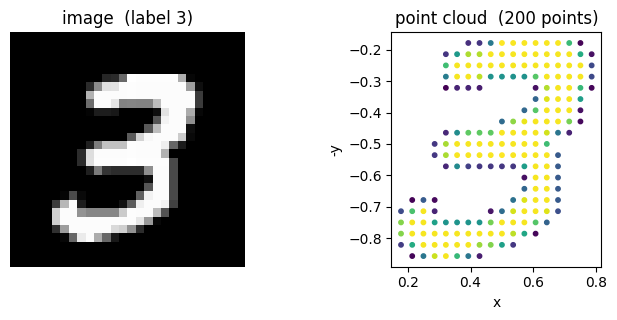

In [6]:
# Visualize one example: image  <->  point cloud
ds_vis, name = load_image_dataset("../data", train=True)
print("Loaded:", name)
img, label = ds_vis[7]
pts = image_to_pointcloud(img)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.3))
ax[0].imshow(img[0], cmap="gray"); ax[0].set_title(f"image  (label {label})"); ax[0].axis("off")
ax[1].scatter(pts[:, 0], -pts[:, 1], c=pts[:, 2], cmap="viridis", s=10)
ax[1].set_title(f"point cloud  ({pts.shape[0]} points)")
ax[1].set_aspect("equal"); ax[1].set_xlabel("x"); ax[1].set_ylabel("-y")
plt.tight_layout(); plt.show()

In [7]:
# Train a DeepSets classifier on the point clouds.
# (We use subsets so this runs in ~a minute on a laptop; raise the ranges for better accuracy.)
full_train = PointCloudImages("../data", train=True)
full_test  = PointCloudImages("../data", train=False)
train_ds = Subset(full_train, range(20000))
test_ds  = Subset(full_test,  range(5000))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  collate_fn=pad_collate)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, collate_fn=pad_collate)

model = DeepSetsClassifier(in_features=3, n_classes=10, pool="sum").to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train):
    model.train(train)
    loss_sum = correct = total = 0
    torch.set_grad_enabled(train)
    for x, mask, y in loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        logits = model(x, mask)
        loss = F.cross_entropy(logits, y)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item() * y.size(0)
        correct  += (logits.argmax(-1) == y).sum().item()
        total    += y.size(0)
    torch.set_grad_enabled(True)
    return loss_sum / total, correct / total

for epoch in range(5):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    te_loss, te_acc = run_epoch(test_loader,  False)
    print(f"epoch {epoch+1}:  train acc {tr_acc:.3f}  |  test acc {te_acc:.3f}")

epoch 1:  train acc 0.116  |  test acc 0.144


epoch 2:  train acc 0.298  |  test acc 0.516


epoch 3:  train acc 0.580  |  test acc 0.615


epoch 4:  train acc 0.671  |  test acc 0.564


epoch 5:  train acc 0.693  |  test acc 0.665


### The key check: is the model *really* permutation-invariant?

We now take a batch, run it, then **shuffle the points within every set** (and the mask the same way) and
run it again. For a true DeepSet the two outputs are identical to floating-point precision — the symmetry
holds *by construction*, not because we trained for it.

In [8]:
model.eval()
x, mask, y = next(iter(test_loader))
x, mask = x.to(device), mask.to(device)
with torch.no_grad():
    out1 = model(x, mask)
    perm = torch.randperm(x.shape[1])                 # one shuffle of the point axis
    out2 = model(x[:, perm, :], mask[:, perm])
print("max |f(x) - f(shuffled x)| =", (out1 - out2).abs().max().item(),
      "  (~0  =>  permutation invariant by construction)")

max |f(x) - f(shuffled x)| = 2.86102294921875e-06   (~0  =>  permutation invariant by construction)


## 6 · The real thing: tagging jets with a Particle Flow Network

Now jets. We read the **JetClass** example file (100k jets) and build a binary task:
**top quark jets (signal)** vs **QCD light-quark/gluon jets (background)** — the standard jet-tagging benchmark.

**Per-particle features.** From each particle's 4-momentum $(p_x,p_y,p_z,E)$ and its position relative to the
jet axis $(\Delta\eta,\Delta\phi)$ we build a small, physically sensible feature vector:

| feature | meaning |
|---|---|
| $\Delta\eta,\ \Delta\phi$ | angular position w.r.t. the jet axis |
| $\log p_T,\ \log E$ | momentum / energy on a log scale (wide dynamic range) |
| $\log(p_T/\sum p_T),\ \log(E/\sum E)$ | momentum / energy *fraction* within the jet |
| $\Delta R=\sqrt{\Delta\eta^2+\Delta\phi^2}$ | distance to the jet axis |

The **PFN** is exactly the DeepSet from §4: embed each particle with $\Phi$, **sum** over particles, classify
with $F$. We reuse `DeepSetsClassifier` unchanged — only `in_features` and `n_classes` differ.

In [9]:
import os
import uproot
import awkward as ak

# The notebook searches a few standard locations for the JetClass example file.
CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError(
        "JetClass example file not found. Download 'JetClass_example_100k.root' from "
        "https://hqu.web.cern.ch/datasets/JetClass/example/ and place it in ../data/.\n"
        f"Searched: {CANDIDATE_PATHS}")
print("Using:", root_path)

Using: /Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root


In [10]:
MAX_PART  = 128     # pad / truncate every jet to this many particles
N_PER_CLS = 8000    # jets per class (top, QCD); raise for better accuracy, lower for speed

tree = uproot.open(root_path)["tree"]
br = tree.arrays(["part_px", "part_py", "part_pz", "part_energy", "part_deta", "part_dphi",
                  "label_QCD", "label_Tbqq", "label_Tbl"])

# Select a balanced subset: QCD (label 0) vs top (Tbqq or Tbl -> label 1)
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)
idx_qcd = np.where(is_qcd)[0][:N_PER_CLS]
idx_top = np.where(is_top)[0][:N_PER_CLS]
sel = np.concatenate([idx_qcd, idx_top])
labels = np.concatenate([np.zeros(len(idx_qcd)), np.ones(len(idx_top))]).astype(np.int64)
print(f"selected {len(idx_qcd)} QCD + {len(idx_top)} top jets")

# Gather the selected jets (still jagged: each jet has a different number of particles)
px, py, pz, e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta, dphi    = br["part_deta"][sel], br["part_dphi"][sel]

# Build per-particle features (vectorised over all jets at once)
pt    = np.sqrt(px**2 + py**2)
dR    = np.sqrt(deta**2 + dphi**2)
sumpt = ak.sum(pt, axis=1)
sume  = ak.sum(e,  axis=1)
logpt    = np.log(pt + 1e-8)
loge     = np.log(e  + 1e-8)
logptrel = np.log(pt / sumpt + 1e-8)
logerel  = np.log(e  / sume  + 1e-8)

FEATURE_NAMES = ["deta", "dphi", "log_pt", "log_e", "log_pt_rel", "log_e_rel", "dR"]
feat_list     = [deta,    dphi,   logpt,    loge,    logptrel,     logerel,     dR]

def pad_feature(f):
    """jagged (Njet, var) -> regular numpy (Njet, MAX_PART), truncating/padding with 0."""
    return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))

X = np.stack([pad_feature(f) for f in feat_list], axis=-1).astype(np.float32)   # (Njet, MAX_PART, F)

# mask + the EFN inputs (kept RAW, i.e. NOT standardized): angles and energy fraction z = pt / sum pt
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)
mask   = (np.arange(MAX_PART)[None, :] < nparts[:, None]).astype(np.float32)    # (Njet, MAX_PART)
angles = np.stack([pad_feature(deta), pad_feature(dphi)], axis=-1).astype(np.float32)
zfrac  = pad_feature(pt / sumpt).astype(np.float32)                             # (Njet, MAX_PART)
print("X:", X.shape, " mask:", mask.shape, " angles:", angles.shape, " z:", zfrac.shape)

selected 8000 QCD + 8000 top jets


X: (16000, 128, 7)  mask: (16000, 128)  angles: (16000, 128, 2)  z: (16000, 128)


In [11]:
# To tensors; shuffle once; split 70/15/15; standardize PFN features with TRAIN statistics.
Xt, Mt, Yt   = torch.from_numpy(X), torch.from_numpy(mask), torch.from_numpy(labels)
AnglesT, Zt  = torch.from_numpy(angles), torch.from_numpy(zfrac)

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(Yt), generator=g)
Xt, Mt, Yt, AnglesT, Zt = Xt[perm], Mt[perm], Yt[perm], AnglesT[perm], Zt[perm]

n = len(Yt); n_tr, n_va = int(0.70 * n), int(0.15 * n)
sl = {"train": slice(0, n_tr), "val": slice(n_tr, n_tr + n_va), "test": slice(n_tr + n_va, n)}

# Standardize PFN features using only real (unpadded) TRAIN particles.
flat = Xt[sl["train"]][Mt[sl["train"]].bool()]           # (n_real_points, F)
feat_mean, feat_std = flat.mean(0), flat.std(0).clamp(min=1e-6)
Xt = (Xt - feat_mean) / feat_std
# NOTE: padded slots become non-zero after standardization, but masked pooling removes them anyway.
print("standardized feature means ~0:", Xt[sl['train']][Mt[sl['train']].bool()].mean(0).numpy().round(2))

standardized feature means ~0: [ 0. -0.  0.  0.  0.  0.  0.]


In [12]:
# Datasets / loaders. PFN consumes (X, mask, y); EFN consumes (angles, z, mask, y).
class TensorSet(Dataset):
    def __init__(self, tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, i): return tuple(t[i] for t in self.tensors)

pfn_loaders = {k: DataLoader(TensorSet((Xt[s], Mt[s], Yt[s])),
                             batch_size=256, shuffle=(k == "train")) for k, s in sl.items()}
efn_loaders = {k: DataLoader(TensorSet((AnglesT[s], Zt[s], Mt[s], Yt[s])),
                             batch_size=256, shuffle=(k == "train")) for k, s in sl.items()}

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

@torch.no_grad()
def evaluate(model, loader, kind="pfn"):
    model.eval(); ys, ps, loss_sum, ntot = [], [], 0.0, 0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        if kind == "pfn":
            x, m, y = batch; logits = model(x, m)
        else:
            a, z, m, y = batch; logits = model(a, z, m)
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item(); ntot += y.size(0)
        ys.append(y.cpu()); ps.append(F.softmax(logits, -1)[:, 1].cpu())
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return {"loss": loss_sum / ntot, "acc": ((p > 0.5).astype(int) == y).mean(),
            "auc": roc_auc_score(y, p), "y": y, "p": p}

def train_model(model, loaders, kind="pfn", epochs=8, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        for batch in loaders["train"]:
            batch = [b.to(device) for b in batch]
            if kind == "pfn":
                x, m, y = batch; logits = model(x, m)
            else:
                a, z, m, y = batch; logits = model(a, z, m)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()
        va = evaluate(model, loaders["val"], kind)
        print(f"epoch {ep+1:2d}:  val loss {va['loss']:.3f}  acc {va['acc']:.3f}  AUC {va['auc']:.4f}")
    return model

def background_rejection(y, p, target_eff=0.5):
    """1 / eps_B at fixed signal efficiency eps_S = target_eff (the standard HEP tagging metric)."""
    fpr, tpr, _ = roc_curve(y, p)
    eps_b = np.interp(target_eff, tpr, fpr)
    return 1.0 / max(eps_b, 1e-12)

In [14]:
# Train the PFN
pfn = DeepSetsClassifier(in_features=len(FEATURE_NAMES),
                         phi_hidden=(64, 128, 128), latent=128,
                         f_hidden=(128, 64), n_classes=2, pool="sum").to(device)
train_model(pfn, pfn_loaders, kind="pfn", epochs=8)

epoch  1:  val loss 0.524  acc 0.760  AUC 0.8568


epoch  2:  val loss 0.377  acc 0.851  AUC 0.9168


epoch  3:  val loss 0.305  acc 0.873  AUC 0.9502


epoch  4:  val loss 0.233  acc 0.907  AUC 0.9688


epoch  5:  val loss 0.225  acc 0.905  AUC 0.9693


epoch  6:  val loss 0.212  acc 0.918  AUC 0.9731


epoch  7:  val loss 0.192  acc 0.921  AUC 0.9776


epoch  8:  val loss 0.181  acc 0.933  AUC 0.9805


DeepSetsClassifier(
  (phi): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
  (f): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

PFN test  AUC = 0.9802   acc = 0.9333
   background rejection 1/eps_B @ eps_S=0.3:  1000000000000.0
   background rejection 1/eps_B @ eps_S=0.5:     403.3
   background rejection 1/eps_B @ eps_S=0.7:     151.2


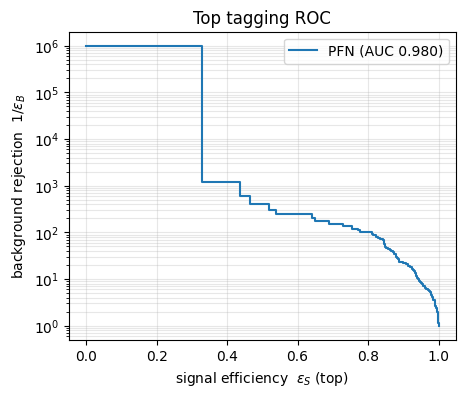

In [15]:
# Evaluate on the held-out test set: AUC + background rejection, and the ROC curve.
res_pfn = evaluate(pfn, pfn_loaders["test"], kind="pfn")
print(f"PFN test  AUC = {res_pfn['auc']:.4f}   acc = {res_pfn['acc']:.4f}")
for eff in (0.3, 0.5, 0.7):
    print(f"   background rejection 1/eps_B @ eps_S={eff}:  {background_rejection(res_pfn['y'], res_pfn['p'], eff):8.1f}")

fpr, tpr, _ = roc_curve(res_pfn["y"], res_pfn["p"])
plt.figure(figsize=(5, 4))
plt.plot(tpr, 1.0 / np.clip(fpr, 1e-6, 1), label=f"PFN (AUC {res_pfn['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency  $\\epsilon_S$ (top)")
plt.ylabel("background rejection  $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("Top tagging ROC"); plt.show()

## 7 · Energy Flow Networks and infrared-&-collinear (IRC) safety

The PFN is powerful but it is *not* guaranteed to respect a deep property of QCD. Detectors and parton
showers introduce two kinds of "harmless" changes that **must not** change a physical observable:

- **Collinear splitting:** one particle splits into two moving in the *same direction*, sharing its momentum.
- **Infrared (soft) emission:** an extra particle appears carrying *vanishing* energy.

An observable that is invariant under both is called **IRC-safe**. The **Energy Flow Network** builds this in:
$$ \text{EFN}(\{x_i\}) \;=\; F\!\Big( \sum_i z_i\, \Phi(\hat{n}_i) \Big),\qquad z_i=\frac{p_{T,i}}{\sum_j p_{T,j}} , $$
where $\Phi$ sees **only the angles** $\hat n_i=(\Delta\eta,\Delta\phi)$ and the per-particle weight $z_i$ is the
**energy fraction**. Why this is IRC-safe:
- *Collinear:* splitting a particle into two at the same angle splits $z$ into $z/2+z/2$ at the same $\Phi$, so
  $\sum_i z_i\Phi(\hat n_i)$ is **unchanged**.
- *Soft:* a particle with $p_T\to 0$ has $z\to 0$, so it contributes **nothing**.

We train an EFN and then *demonstrate* both guarantees numerically.

In [16]:
class EFN(nn.Module):
    """Energy Flow Network (IRC-safe):  F( sum_i z_i * Phi(angles_i) ).
       angles: (B, N, 2) = (deta, dphi)   z: (B, N) energy fractions   mask: (B, N)
    """
    def __init__(self, n_angle=2, phi_hidden=(64, 128, 128), latent=128,
                 f_hidden=(128, 64), n_classes=2):
        super().__init__()
        self.phi = make_mlp(n_angle, phi_hidden, latent)
        self.f   = make_mlp(latent, f_hidden, n_classes)
    def forward(self, angles, z, mask):
        h = self.phi(angles)                       # (B, N, latent)
        w = (z * mask).unsqueeze(-1)               # zero out padded weights
        return self.f((w * h).sum(dim=1))          # energy-weighted sum, then classify

efn = EFN(n_angle=2, n_classes=2).to(device)
train_model(efn, efn_loaders, kind="efn", epochs=8)

epoch  1:  val loss 0.653  acc 0.598  AUC 0.8110


epoch  2:  val loss 0.488  acc 0.777  AUC 0.8204


epoch  3:  val loss 0.471  acc 0.786  AUC 0.8415


epoch  4:  val loss 0.477  acc 0.782  AUC 0.8532


epoch  5:  val loss 0.463  acc 0.783  AUC 0.8592


epoch  6:  val loss 0.452  acc 0.791  AUC 0.8642


epoch  7:  val loss 0.456  acc 0.778  AUC 0.8651


epoch  8:  val loss 0.449  acc 0.785  AUC 0.8671


EFN(
  (phi): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
  (f): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

PFN  AUC = 0.9802
EFN  AUC = 0.8676   (IRC-safe; uses only angles + energy fractions)


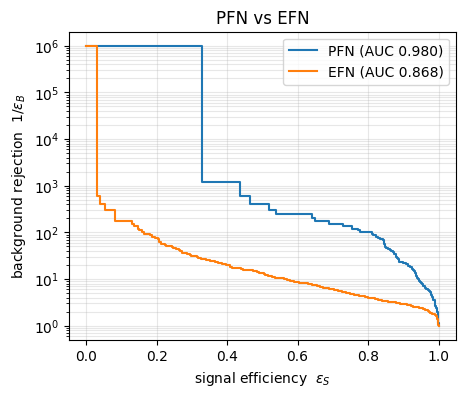

In [17]:
# Compare PFN vs EFN on the same test set.
res_efn = evaluate(efn, efn_loaders["test"], kind="efn")
print(f"PFN  AUC = {res_pfn['auc']:.4f}")
print(f"EFN  AUC = {res_efn['auc']:.4f}   (IRC-safe; uses only angles + energy fractions)")

plt.figure(figsize=(5, 4))
for res, lbl in [(res_pfn, "PFN"), (res_efn, "EFN")]:
    fpr, tpr, _ = roc_curve(res["y"], res["p"])
    plt.plot(tpr, 1.0 / np.clip(fpr, 1e-6, 1), label=f"{lbl} (AUC {res['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency  $\\epsilon_S$")
plt.ylabel("background rejection  $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("PFN vs EFN"); plt.show()

### Demonstrating IRC safety

We take one real top jet and apply the two "harmless" deformations, then watch each model's predicted
$p(\text{top})$. The **EFN output should barely move** (it is invariant *by construction*); the **PFN has no
such guarantee** and can shift, because it feeds every particle's $p_T$/$E$ through $\Phi$.

In [18]:
# Helpers: build each model's input from a raw single-jet particle list, then read off p(top).
@torch.no_grad()
def pfn_prob(pt, e, deta, dphi):
    pt, e, deta, dphi = map(np.asarray, (pt, e, deta, dphi))
    dR = np.sqrt(deta**2 + dphi**2)
    feats = np.stack([deta, dphi, np.log(pt + 1e-8), np.log(e + 1e-8),
                      np.log(pt / pt.sum() + 1e-8), np.log(e / e.sum() + 1e-8), dR], axis=-1).astype(np.float32)
    x = (torch.from_numpy(feats)[None] - feat_mean) / feat_std       # standardize as in training
    m = torch.ones(1, x.shape[1])
    return F.softmax(pfn(x.to(device), m.to(device)), -1)[0, 1].item()

@torch.no_grad()
def efn_prob(pt, e, deta, dphi):
    pt = np.asarray(pt)
    z = (pt / pt.sum()).astype(np.float32)
    a = torch.from_numpy(np.stack([np.asarray(deta), np.asarray(dphi)], axis=-1).astype(np.float32))[None]
    m = torch.ones(1, a.shape[1])
    return F.softmax(efn(a.to(device), torch.from_numpy(z)[None].to(device), m.to(device)), -1)[0, 1].item()

def collinear_split(pt, e, eta, phi, k):                 # split particle k into two collinear halves
    return (np.append(np.delete(pt, k), [pt[k]/2, pt[k]/2]),
            np.append(np.delete(e,  k), [e[k]/2,  e[k]/2]),
            np.append(np.delete(eta, k), [eta[k], eta[k]]),
            np.append(np.delete(phi, k), [phi[k], phi[k]]))

def add_soft(pt, e, eta, phi, frac=1e-3):                # add one very soft particle
    return (np.append(pt, pt.sum()*frac), np.append(e, e.sum()*frac),
            np.append(eta, 0.0), np.append(phi, 0.0))

# A raw top jet (unpadded), straight from the file
j = int(idx_top[0])
rpt  = ak.to_numpy(np.sqrt(br["part_px"][j]**2 + br["part_py"][j]**2))
re   = ak.to_numpy(br["part_energy"][j])
reta = ak.to_numpy(br["part_deta"][j]); rphi = ak.to_numpy(br["part_dphi"][j])

k = int(np.argmax(rpt))
csp = collinear_split(rpt, re, reta, rphi, k)
sft = add_soft(rpt, re, reta, rphi)

print("                     PFN p(top)   EFN p(top)")
print(f"baseline             {pfn_prob(rpt,re,reta,rphi):8.4f}   {efn_prob(rpt,re,reta,rphi):8.4f}")
print(f"collinear split      {pfn_prob(*csp):8.4f}   {efn_prob(*csp):8.4f}")
print(f"soft particle added  {pfn_prob(*sft):8.4f}   {efn_prob(*sft):8.4f}")
print("\nEFN columns should be essentially constant (IRC-safe by construction);")
print("the PFN has no such guarantee.")

                     PFN p(top)   EFN p(top)
baseline               0.9901     0.9130
collinear split        0.9894     0.9130
soft particle added    0.9902     0.9127

EFN columns should be essentially constant (IRC-safe by construction);
the PFN has no such guarantee.


## 8 · Exercises

1. **Pooling matters.** Re-train the warm-up classifier with `pool="mean"`. Then construct two point clouds
   that `mean`-pooling cannot tell apart but `sum`-pooling can (hint: duplicate every point). What does this
   say about the Deep Sets theorem's preference for the sum?
2. **Jet-mass regression.** Replace the classifier head with a single regression output and train the PFN to
   predict the jet (soft-drop) mass. Use an MSE loss; report the resolution. Which features matter most?
3. **Multiclass.** Extend from top-vs-QCD to the full set of JetClass labels (QCD, H, W/Z, top). Plot a
   confusion matrix. Which classes are confused, and does that make physical sense?
4. **How IRC-safe is the PFN in practice?** Sweep the collinear/soft deformation strength and plot how far
   each model's output drifts. The EFN is flat by construction — by how much does the trained PFN move?
5. **Attention pooling (teaser for Module 3).** Replace `masked_sum` with a learned attention-weighted sum
   $\sum_i \alpha_i\, \phi(x_i)$ where $\alpha_i = \mathrm{softmax}_i(w^\top \phi(x_i))$. Does it help? You have
   just built a (very small) Set Transformer pooling layer.

## 9 · Recap, and the bridge to Module 2

- A jet is a **set**; the right inductive bias is **permutation invariance**.
- **Deep Sets**: embed each particle with $\phi$, **pool** (sum/mean), decode with $\rho$. The pool is the
  invariant **aggregation** — the atom we will reuse for the rest of the course.
- **PFN** = Deep Sets on particle features. **EFN** = the IRC-safe variant that pools angles weighted by
  energy fractions — a *physics guarantee written into the architecture*.
- We evaluated like physicists: **ROC / AUC** and **background rejection at fixed signal efficiency**.

**What's missing?** DeepSets treats every particle *independently* before pooling — it never lets two
particles "talk". But jet substructure is all about *relations* between particles (prongs, subjets, angles
between hard emissions). In **Module 2** we add the next ingredient — **edges** — turning the set into a
**graph** and the pool into **message passing** (EdgeConv, ParticleNet). Everything you built here carries
straight over: the neighbourhood aggregation in a GNN is exactly a small DeepSet.